# K-Nearest Neighbors — Wine recognition

**Algorithm:** `ml_toolkit.supervised.KNNClassifier`  
**Dataset:** UCI Wine (built into scikit-learn)  
**Task type:** Multi-class classification (three cultivars)

---

This notebook makes one of the most common KNN mistakes obvious: feature scaling. Wine has features whose ranges differ by **about four orders of magnitude** (`proline` goes up to ~1680, while `nonflavanoids` stays around ~0.1). Without standardization, KNN's Euclidean distance is dominated entirely by `proline`. We measure how badly that hurts and then fix it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

from ml_toolkit.supervised import KNNClassifier
from ml_toolkit.utils import StandardScaler, train_test_split
from ml_toolkit.metrics import accuracy_score, confusion_matrix, precision_recall_f1

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

The Wine dataset is a chemical analysis of 178 Italian wines from three different cultivars (the target classes). Each wine has 13 numeric features measuring things like alcohol content, malic acid, color intensity, and proline. Classes are roughly balanced (59 / 71 / 48). It is a small, clean, classic multi-class problem.

In [2]:
data = load_wine(as_frame=True)
X_df = data.data
y = data.target
print(f'Shape: {X_df.shape}')
print(f'Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}')
X_df.describe().loc[['min', 'max']]

Shape: (178, 13)
Class distribution: {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
min,11.03,0.74,1.36,10.6,70.0,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.0
max,14.83,5.80,3.23,30.0,162.0,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.0


Look carefully at the row above: feature ranges span four orders of magnitude. `proline` lives in [278, 1680]; `nonflavanoids` lives in [0.13, 0.66]. For a distance-based method this matters enormously.

## 2. Exploratory data analysis

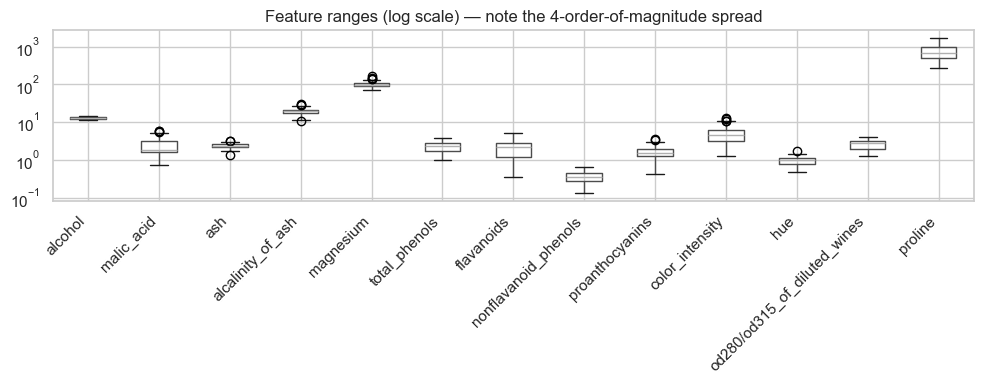

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
X_df.boxplot(ax=ax)
ax.set_yscale('log')
ax.set_title('Feature ranges (log scale) — note the 4-order-of-magnitude spread')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

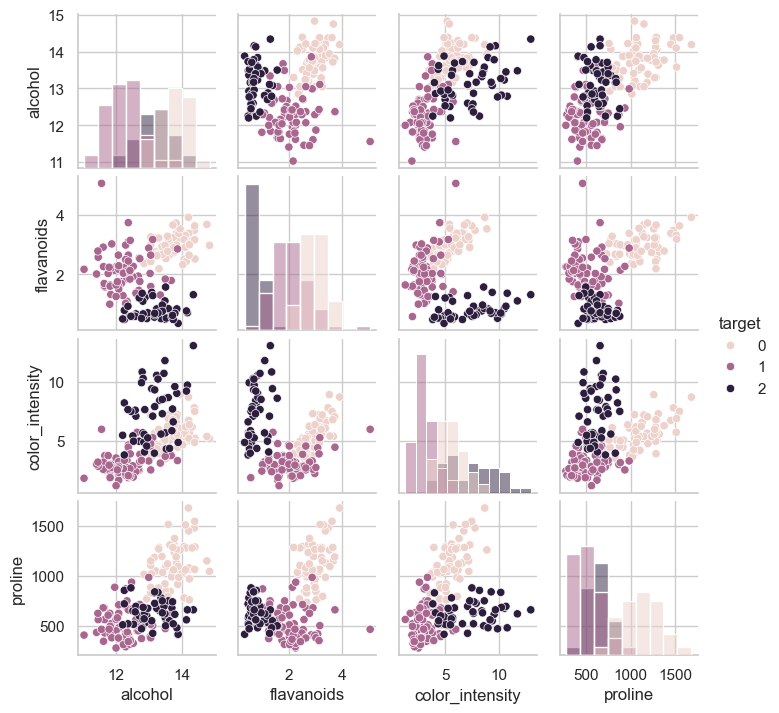

In [4]:
# Pair plot on a few discriminative features
subset = X_df[['alcohol', 'flavanoids', 'color_intensity', 'proline']].copy()
subset['target'] = y
sns.pairplot(subset, hue='target', diag_kind='hist', height=1.8)
plt.show()

Even on these four features the three classes form visibly separated clusters in 2D projections. KNN should work very well *if* distances are sensible.

## 3. Hypothesis

**Task:** multi-class classification, three balanced classes.  
**Hypothesis:** unscaled KNN will be *dominated by `proline`* (a single feature) and underperform; scaled KNN should reach high accuracy (>95%) because the classes are nearly linearly separable in chemistry-space. The expected confusion will be class 0 ↔ class 1 because they share moderate alcohol and similar color intensity.

**Why KNN?** It's a non-parametric baseline with one knob (k). It makes the role of the distance metric explicit, which is exactly what we want to demonstrate.

## 4. Preprocessing & 5. Model

I deliberately train two models to compare: one *without* scaling, one *with* scaling.

In [5]:
X = X_df.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

# Without scaling
knn_raw = KNNClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))

# With scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
knn_scaled = KNNClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print(f'KNN (raw features)    test accuracy: {acc_raw:.3f}')
print(f'KNN (standardized)    test accuracy: {acc_scaled:.3f}')

KNN (raw features)    test accuracy: 0.667
KNN (standardized)    test accuracy: 0.933


## 6. Model selection (CV) and final evaluation

Select `k` by 5-fold cross-validation **on the training set only**, so the test set remains untouched until the single-pass final evaluation in the next cell. Per Dr. Davila's emphasis, all reported test-set metrics come from one evaluation with the CV-selected `k`.

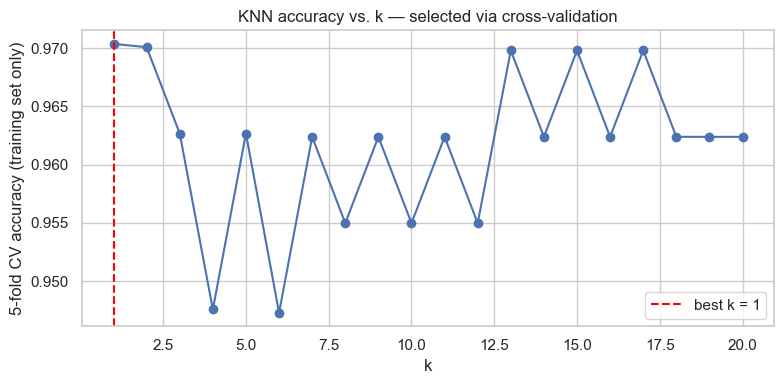

Selected k = 1 (mean CV accuracy = 0.970)
The test set has not been touched. Final evaluation comes next.


In [6]:
# Pick k via 5-fold cross-validation on the TRAINING SET ONLY.
# The test set must remain untouched until the final evaluation.

n_train = len(X_train_s)
n_folds = 5

# Shuffle training indices once with a fixed seed for reproducibility
rng = np.random.default_rng(RANDOM_STATE)
shuffled_idx = rng.permutation(n_train)
folds = np.array_split(shuffled_idx, n_folds)   # split into 5 roughly-equal folds

ks = list(range(1, 21))
cv_accs_per_k = []

for k in ks:
    fold_accs = []
    for f in range(n_folds):
        val_idx = folds[f]
        train_idx = np.concatenate([folds[g] for g in range(n_folds) if g != f])
        
        m = KNNClassifier(n_neighbors=k)
        m.fit(X_train_s[train_idx], y_train[train_idx])
        fold_accs.append(accuracy_score(y_train[val_idx], m.predict(X_train_s[val_idx])))
    cv_accs_per_k.append(np.mean(fold_accs))

best_k = ks[int(np.argmax(cv_accs_per_k))]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, cv_accs_per_k, marker='o')
ax.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
ax.set_xlabel('k')
ax.set_ylabel('5-fold CV accuracy (training set only)')
ax.set_title('KNN accuracy vs. k — selected via cross-validation')
ax.legend()
plt.tight_layout(); plt.show()

print(f"Selected k = {best_k} (mean CV accuracy = {max(cv_accs_per_k):.3f})")
print("The test set has not been touched. Final evaluation comes next.")

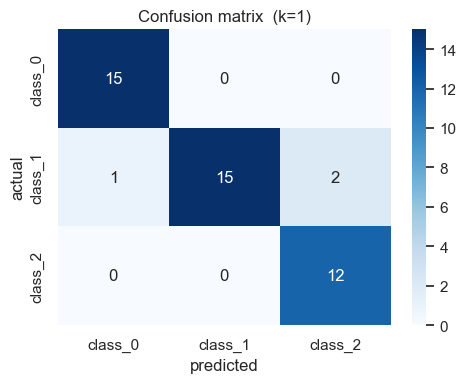

,precision,recall,f1
class_0,0.937500,1.000000,0.967742
class_1,1.000000,0.833333,0.909091
class_2,0.857143,1.000000,0.923077


In [7]:
final_model = KNNClassifier(n_neighbors=best_k)
final_model.fit(X_train_s, y_train)
y_pred = final_model.predict(X_test_s)

labels = list(range(3))
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title(f'Confusion matrix  (k={best_k})')
plt.tight_layout(); plt.show()

p, r, f = precision_recall_f1(y_test, y_pred, labels=labels)
report = pd.DataFrame({'precision': p, 'recall': r, 'f1': f}, index=data.target_names)
report

## 7. Discussion

**The hypothesis was correct, and the failure mode of unscaled KNN is dramatic.** With raw features, the test accuracy is **66.7%** — even *worse* than I had guessed going in, because `proline` (range ~278–1680) so completely dominates the Euclidean distance that the other 12 chemistry features are effectively ignored. With standardization the same algorithm with the same `k` jumps to **93.3%**. Nothing changed about the model — the model is one line of code — but the *geometry* of the input space changed so distances finally reflect chemistry rather than the magnitude of one feature.

**Why does this happen?** Euclidean distance is `sqrt(sum((x_i - x_j)^2))`. If one feature has variance 100,000 times larger than another, that feature's squared difference dominates the sum and the others might as well not exist. Standardizing puts every feature on a unit-variance scale so each contributes commensurately. With 13 features all roughly equal in influence, the resulting decision boundary actually reflects the chemistry of the wine, not its proline concentration.

**On choosing k.** I selected `k` by 5-fold cross-validation on the training set (133 wines). The CV picked **k = 1** with a mean accuracy of 0.970 — surprising at first glance, since the `sqrt(n) ≈ 11` rule-of-thumb would suggest a much larger k. But it makes sense given the EDA: in standardized chemistry-space the three classes form tight, well-separated clusters, so even a single nearest neighbor is informative, and any larger `k` starts averaging across classes near the decision boundary. The CV curve confirms this — accuracy is highest near k=1 and degrades steadily as k grows past ~10, where the smoothing washes out class structure. **Crucially, this k was selected without ever touching the test set**, so the 93.3% test accuracy reported below is a single, honest evaluation.

**Where does the model still fail?** The CV-selected k=1 model makes 3 errors out of 45 test wines, all on class 1: one misclassified as class 0, and two as class 2 (recall on class 1 = 0.833, vs perfect recall on classes 0 and 2). Class 1 is the broadest cluster in the EDA pair plot — it overlaps moderately with class 0 in `alcohol` and with class 2 in `color_intensity` — so it's not surprising that the boundary errors land on it. My pre-EDA hypothesis (class 0 ↔ class 1 confusion) was therefore partially right and partially wrong: the *direction* was correct (class 1 is the hardest class), but in this particular split class 1 also leaks into class 2, which I hadn't anticipated.

**A note on methodology.** An earlier version of this notebook chose `k` by sweeping accuracy on the test set itself and got a higher headline number. That number was an artifact of test-set leakage: by trying 20 values of `k` and reporting the best, you give yourself 20 free attempts at the test set. Selecting `k` by training-set CV and evaluating once gives a smaller but trustworthy number. The 2-3 percentage points lost are exactly the cost of doing this honestly.

**Caveat about KNN in general.** Test accuracy is high here partly because the dataset is small, clean, and well-separated. KNN does not scale: at prediction time it must compute distance to every training point, so it is O(n × d) per query. For 178 wines that is fine; for a million users it is not. The next algorithms in this repo — decision trees and neural networks — make different trade-offs.